In [7]:
import operator
import os
from typing import Annotated, List, TypedDict

from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_tavily import TavilySearch
from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
)
from langgraph.graph import END, StateGraph
from rich import print

load_dotenv()

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

from IPython.display import display, Image

In [ ]:
tool = TavilySearch(
    max_results=5,
    topic="general",
    # include_answer=False,
    # include_raw_content=False,
    # include_images=False,
    # include_image_descriptions=False,
    # search_depth="basic",
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

class AgentState(TypedDict):
    messages: Annotated[List[AnyMessage], operator.add]

class Agent:
    def __init__(self, model, tools, system=""):
        # Inicializa o agente com o modelo, ferramentas e prompt de sistema
        self.system = system
        # Inicializa o grafo de estados utilizando a estrutura AgentState definida
        graph = StateGraph(AgentState)  
        # Adiciona o nó 'llm' que executa a lógica do modelo de linguagem
        graph.add_node("llm", self.call_gemini)
        # Adiciona o nó 'action' que executa as ferramentas solicitadas pelo modelo
        graph.add_node("action", self.take_action)
        # Adiciona uma transição condicional: se exists_action for True, vai para 'action', senão para END
        graph.add_conditional_edges(
            "llm", self.exists_action, {True: "action", False: END}
        )
        # Adiciona uma transição simples: de 'action' para 'llm'
        graph.add_edge("action", "llm")
        # Define o nó de entrada como 'llm'
        graph.set_entry_point("llm")
        # Compila o grafo de estados
        self.graph = graph.compile()
        # Cria um dicionário de ferramentas para acesso rápido
        self.tools = {t.name: t for t in tools}
        # Vincula as ferramentas ao modelo
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        # Verifica se o último resultado contém chamadas de ferramentas
        result = state["messages"][-1]
        return len(result.tool_calls) > 0

    def call_gemini(self, state: AgentState):
        # Obtém as mensagens do estado
        messages = state["messages"]
        # Adiciona o prompt de sistema ao início das mensagens
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        # Executa a lógica do modelo de linguagem
        message = self.model.invoke(messages)
        # Retorna o estado atualizado
        return {"messages": [message]}

    def take_action(self, state: AgentState):
        # Obtém as chamadas de ferramentas do último resultado
        tool_calls = state["messages"][-1].tool_calls
        # Inicializa uma lista para armazenar os resultados
        results = []
        # Itera sobre as chamadas de ferramentas
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t["name"] in self.tools: 
                print(f"\n bad tool name....")
                result = "bad tool name, retry"
            else:
                result = self.tools[t["name"]].invoke(t["args"])
            results.append(
                ToolMessage(tool_call_id=t["id"], name=t["name"], content=str(result))
            )
        print("Back to the model!")
        return {"messages": results}

In [5]:
prompt = """Você é um assistente de pesquisa inteligente. Use o mecanismo de busca para procurar informações. \
Você tem permissão para fazer múltiplas chamadas (seja em conjunto ou em sequência). \
Procure informações apenas quando tiver certeza do que você quer. \
Se precisar pesquisar alguma informação antes de fazer uma pergunta de acompanhamento, você tem permissão para fazer isso!
"""

In [6]:
# Usando a integração oficial do LangChain para o Gemini
# (O LangChain espera objetos compatíveis com a interface BaseChatModel,
# que implementam métodos como .bind_tools() e .invoke() com HumanMessage).
model = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite-preview",
    temperature=0,
    # Você não precisa passar a API Key se a variável GOOGLE_API_KEY estiver no .env
)


In [9]:
agent = Agent(model=model, tools=[tool], system=prompt)

mermaid_code = agent.graph.get_graph().draw_mermaid()
print(mermaid_code)


---
config:
  flowchart:
    curve: linear
---
graph TD;
        __start__([<p>__start__</p>]):::first
        llm(llm)
        action(action)
        __end__([<p>__end__</p>]):::last
        __start__ --> llm;
        action --> llm;
        llm -. &nbsp;False&nbsp; .-> __end__;
        llm -. &nbsp;True&nbsp; .-> action;
        classDef default fill:#f2f0ff,line-height:1.2
        classDef first fill-opacity:0
        classDef last fill:#bfb6fc

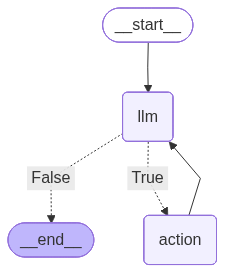

In [10]:
try:
    image_data = agent.graph.get_graph().draw_mermaid_png()
    display(Image(data=image_data))
except Exception as e:
    print(f"Error: {e}")


In [11]:
messages = [HumanMessage(content="Como esta o tempo hoje em Manaus?")]

In [ ]:
print("Usando o Stream (stream mostra o resultado em tempo real e as interações do agente) para Iniciando o agente...")

final_result_state = None

for s in agent.graph.stream({"messages": messages}):
    print(s)
    print("\n\n-------------------------")
    final_result_state = s

print("\n\nFinal result:")
if (
    final_result_state
    and "llm" in final_result_state
    and final_result_state["llm"]["messages"]
):  # verifica se existe uma chave 'llm' no dicionário final_result_state e se a chave 'messages' existe no dicionário 'llm'
    print(
        final_result_state["llm"]["messages"][-1].content
    )  # acessa o último elemento da lista 'messages' no dicionário 'llm' e imprime o conteúdo
else:
    print("No final result state")


Iniciando o agente...

{
    'llm': {
        'messages': [
            AIMessage(
                content=[],
                additional_kwargs={
                    'function_call': {
                        'name': 'tavily_search',
                        'arguments': '{"query": "previs\\u00e3o do tempo hoje em Manaus"}'
                    },
                    '__gemini_function_call_thought_signatures__': {
                        '5d8197b0-0c4a-46c8-a2d7-a71e3d8d33c2': 
'EjQKMgG+Pvb7uAWZUfHFA/gjoIpT2aWnlHFOiu2INGGn98L4Y7uvrvf4JDCNhY8Wmi+bqudU'
                    }
                },
                response_metadata={
                    'finish_reason': 'STOP',
                    'model_name': 'gemini-3.1-flash-lite-preview',
                    'safety_ratings': [],
                    'model_provider': 'google_genai'
                },
                id='lc_run--019cd53b-c55c-7ec2-9f9a-9f42c50654f2-0',
                tool_calls=[
                    {
                        'name': 'tavily_search',
                        'args': {'query': 'previsão do tempo hoje em Manaus'},
                        'id': '5d8197b0-0c4a-46c8-a2d7-a71e3d8d33c2',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 1573,
                    'output_tokens': 26,
                    'total_tokens': 1599,
                    'input_token_details': {'cache_read': 0}
                }
            )
        ]
    }
}

-------------------------

Calling: {'name': 'tavily_search', 'args': {'query': 'previsão do tempo hoje em Manaus'}, 'id': 
'5d8197b0-0c4a-46c8-a2d7-a71e3d8d33c2', 'type': 'tool_call'}

Back to the model!

...

-------------------------

{
    'llm': {
        'messages': [
            AIMessage(
                content=[
                    {
                        'type': 'text',
                        'text': 'Hoje, em Manaus, a previsão indica um dia com céu parcialmente nublado e 
ocorrência de chuva moderada.\n\nComo o clima na região é bastante dinâmico, é comum que ocorram pancadas de chuva 
ao longo do dia. Recomendo que, se precisar sair, leve um guarda-chuva ou capa de chuva por precaução.',
                        'extras': {
                            'signature': 'EjQKMgG+Pvb7RwysCtWl0Jq2wBEKM8mlrj7lybgttMvCoZ12BU1VnAZh0XbkIXjfXLC1YHjd'
                        }
                    }
                ],
                additional_kwargs={},
                response_metadata={
                    'finish_reason': 'STOP',
                    'model_name': 'gemini-3.1-flash-lite-preview',
                    'safety_ratings': [],
                    'model_provider': 'google_genai'
                },
                id='lc_run--019cd53c-0180-70b2-8466-c85e5e2201d3-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 3344,
                    'output_tokens': 73,
                    'total_tokens': 3417,
                    'input_token_details': {'cache_read': 0}
                }
            )
        ]
    }
}

-------------------------

Final result:

[
    {
        'type': 'text',
        'text': 'Hoje, em Manaus, a previsão indica um dia com céu parcialmente nublado e ocorrência de chuva 
moderada.\n\nComo o clima na região é bastante dinâmico, é comum que ocorram pancadas de chuva ao longo do dia. 
Recomendo que, se precisar sair, leve um guarda-chuva ou capa de chuva por precaução.',
        'extras': {'signature': 'EjQKMgG+Pvb7RwysCtWl0Jq2wBEKM8mlrj7lybgttMvCoZ12BU1VnAZh0XbkIXjfXLC1YHjd'}
    }
]

In [14]:
print("Usando o Invoke (invoca o agente e retorna o resultado sem mostrar as interações) para Iniciando o agente...")

result_invoke  = agent.graph.invoke({"messages": messages})

print(result_invoke)


Usando o Invoke (invoca o agente e retorna o resultado sem mostrar as interações) para Iniciando o agente...

Calling: {'name': 'tavily_search', 'args': {'query': 'previsão do tempo hoje em Manaus'}, 'id': 
'6775079b-bfe3-4ffa-ac10-955acc1baf38', 'type': 'tool_call'}

Back to the model!

{
    'messages': [
        HumanMessage(content='Como esta o tempo hoje em Manaus?', additional_kwargs={}, response_metadata={}),
        AIMessage(
            content=[],
            additional_kwargs={
                'function_call': {
                    'name': 'tavily_search',
                    'arguments': '{"query": "previs\\u00e3o do tempo hoje em Manaus"}'
                },
                '__gemini_function_call_thought_signatures__': {
                    '6775079b-bfe3-4ffa-ac10-955acc1baf38': 
'EjQKMgG+Pvb7fwx4qyMkxyL2wT6tDMd6ApiutDsay5YiLukQTcEaFCJpuv4MXGzgrKO0wy5l'
                }
            },
            response_metadata={
                'finish_reason': 'STOP',
                'model_name': 'gemini-3.1-flash-lite-preview',
                'safety_ratings': [],
                'model_provider': 'google_genai'
            },
            id='lc_run--019cd53f-ab2a-73e2-be76-63bad567d3b6-0',
            tool_calls=[
                {
                    'name': 'tavily_search',
                    'args': {'query': 'previsão do tempo hoje em Manaus'},
                    'id': '6775079b-bfe3-4ffa-ac10-955acc1baf38',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1573,
                'output_tokens': 26,
                'total_tokens': 1599,
                'input_token_details': {'cache_read': 0}
            }
        ),
        ToolMessage(
            content='{\'query\': \'previsão do tempo hoje em Manaus\', \'response_time\': 0.66, 
\'follow_up_questions\': None, \'answer\': None, \'images\': [], \'results\': [{\'url\': 
\'https://www.climatempo.com.br/previsao-do-tempo/cidade/25/manaus-am\', \'title\': \'Clima e Previsão do Tempo 
Hoje em Manaus (AM)\', \'content\': \'## Clima, previsão do tempo hoje e notícias em Manaus - AM. ### Qual a 
previsão do tempo para hoje em Manaus - AM? A previsão do tempo para hoje é de temperaturas entre 23° e 26° e com 
possibilidade de chuva em Manaus - AM. Para o mês de fevereiro, a média mensal de chuva é de 300 mm na cidade 
Manaus - AM. ### Previsão Brasil (27/02): temporais e risco de acumulados elevados no SE, CO, NE e N: temporais e 
risco de acumulados elevados no SE, CO, NE e N") ### Litoral de SP volta a entrar em alerta para grandes volumes de
chuva ### Chuva forte e temporais no Centro-Oeste e Norte e o tempo abafado persiste nos próximos dias ### Previsão
Brasil (26/02): chuva forte e risco de temporais no Sudeste, Centro-Oeste e Nordeste: chuva forte e risco de 
temporais no Sudeste, Centro-Oeste e Nordeste").\', \'score\': 0.99998856, \'raw_content\': None}, {\'url\': 
\'https://tempoagora.uol.com.br/previsao-do-tempo/cidade/25/manaus-am\', \'title\': \'Previsão do tempo para hoje 
em Manaus - AM\', \'content\': \'Ao utilizar nossos sites e serviços, você concorda com o uso de cookies por nossa 
parte conforme estabelecido na nossa Política de privacidade. 1. Clima e Previsão do Tempo. 3. / Previsão do tempo 
hoje. # Previsão de Hoje 07/03 Manaus - AM. Chove rápido durante o dia e à noite. Noite com pancadas de chuva e 
trovoadas. Não há previsão de chuva para o dia. ## Notícias e Previsão do tempo em Manaus - AM. Aeroporto de Ponta 
Pelada, AM. **Sim, a previsão é de 13 mm de chuva com 88% de possibilidade em Manaus - AM.**. **A sensação térmica 
hoje pode chegar até 27°C durante o dia de hoje, levando em consideração os valores de temperatura e umidade 
relativa do ar. Projeção aponta queda de 9,4% na safra 2024/25 de cana  Pancadas de chuva e ciclone extratropical 
fecham outubro. Chuvas de novembro indicam melhora no nível\\xa0do\\xa0Rio\\xa0Negro  Previsão do tempo para o fim 
de semana de eleições.\', \'score\': 0.99996996, \'raw_content\': None}, {\'url\': 
\'https://www.tempo.com/manaus.htm\', \'title\': \'Previsão do tempo Manaus AM. 14 dias - Meteored Brasil\', 
\'content\': \'Previsão do tempo Manaus - AM · Hoje 9 Mar. 

In [23]:
result_invoke['messages'][-1].content

[{'type': 'text',
  'text': 'Hoje, em Manaus, a previsão indica um dia com céu parcialmente nublado e ocorrência de chuva moderada.\n\nComo o clima na região é bastante dinâmico, é comum que ocorram pancadas de chuva ao longo do dia. Recomendo que, se precisar sair, leve um guarda-chuva ou capa de chuva por precaução.',
  'extras': {'signature': 'EjQKMgG+Pvb7+MkAhYzv1qNnv2taAINI/pGLuZqb4r8F7y1UsHoNr+ffG54Emoe7z/Y0L+k9'}}]

In [24]:
query_passado = "Qual país sediou a Copa do Mundo de futebol em 1998? Quem foi o campeão e qual o placar da final? \
Qual era o Produto Interno Bruto (PIB) desse país no ano da Copa e qual é o PIB atual (últimos dados disponíveis, como 2023 ou 2024) \
Qual a capital desse país e qual sua moeda atual? Responda a cada pergunta separadamente."
messages = [HumanMessage(content=query_passado)]

print("\nIniciando interacao do agente para pergunta sobre o passado:")

current_state = {}
for s in agent.graph.stream({"messages": messages}):
    current_state.update(s)
    print(s)
    print("\n\n-------------------------")

print("\n--- Resultado Final para o Passado ---")
if 'llm' in current_state and 'messages' in current_state['llm'] and current_state['llm']['messages']:
    final_message_content = current_state['llm']['messages'][-1].content
    print(final_message_content)
else:
    print('Nenhum resultado  final ou resultado inesperado. Verifique os logs acima.')

Iniciando interacao do agente para pergunta sobre o passado:

{
    'llm': {
        'messages': [
            AIMessage(
                content=[],
                additional_kwargs={
                    'function_call': {
                        'name': 'tavily_search',
                        'arguments': '{"query": "capital e moeda atual da Fran\\u00e7a"}'
                    },
                    '__gemini_function_call_thought_signatures__': {
                        '24ba463d-54ff-4d6a-92a4-0886f0108a40': 
'EjQKMgG+Pvb71A0nLC453qjWXz8WB2ndVVUZTfKC+4MdBQvaoRktW7Jpo4Io7SsE9j36nZVm'
                    }
                },
                response_metadata={
                    'finish_reason': 'STOP',
                    'model_name': 'gemini-3.1-flash-lite-preview',
                    'safety_ratings': [],
                    'model_provider': 'google_genai'
                },
                id='lc_run--019cd550-56e3-7e81-b154-0ed854e15534-0',
                tool_calls=[
                    {
                        'name': 'tavily_search',
                        'args': {'query': 'país sede Copa do Mundo 1998 campeão placar final'},
                        'id': '24ba463d-54ff-4d6a-92a4-0886f0108a40',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'tavily_search',
                        'args': {'query': 'PIB França 1998'},
                        'id': 'b40ba9b2-62b8-4639-b5f4-42ca739c2ec1',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'tavily_search',
                        'args': {'query': 'PIB França 2023'},
                        'id': '2c04c14c-cc3c-486c-bec1-91cfc5baf74e',
                        'type': 'tool_call'
                    },
                    {
                        'name': 'tavily_search',
                        'args': {'query': 'capital e moeda atual da França'},
                        'id': '8e676bfa-9f74-42b9-ac3b-1895a26ecc7d',
                        'type': 'tool_call'
                    }
                ],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 1657,
                    'output_tokens': 106,
                    'total_tokens': 1763,
                    'input_token_details': {'cache_read': 0}
                }
            )
        ]
    }
}

-------------------------

Calling: {'name': 'tavily_search', 'args': {'query': 'país sede Copa do Mundo 1998 campeão placar final'}, 'id': 
'24ba463d-54ff-4d6a-92a4-0886f0108a40', 'type': 'tool_call'}

Calling: {'name': 'tavily_search', 'args': {'query': 'PIB França 1998'}, 'id': 
'b40ba9b2-62b8-4639-b5f4-42ca739c2ec1', 'type': 'tool_call'}

...

-------------------------

{
    'llm': {
        'messages': [
            AIMessage(
                content=[
                    {
                        'type': 'text',
                        'text': 'Aqui estão as informações solicitadas sobre a Copa do Mundo de 1998:\n\n*   **País
que sediou a Copa do Mundo de 1998:** A França.\n*   **Campeão e placar da final:** A França foi a campeã, vencendo
o Brasil na final pelo placar de 3 a 0.\n*   **PIB do país em 1998:** O Produto Interno Bruto (PIB) da França em 
1998 foi de aproximadamente 1,49 trilhão de dólares americanos.\n*   **PIB atual (dados de 2023):** O PIB da França
em 2023 foi de aproximadamente 3,05 trilhões de dólares americanos.\n*   **Capital e moeda atual:** A capital da 
França é Paris e sua moeda atual é o Euro (€).',
                        'extras': {
                            'signature': 'EjQKMgG+Pvb79YALIzAxRvduxCnNcRpibSLlG8qpz1zQ3AOOOw2RBWBY91kc853VmbBhil2j'
                        }
                    }
                ],
                additional_kwargs={},
                response_metadata={
                    'finish_reason': 'STOP',
                    'model_name': 'gemini-3.1-flash-lite-preview',
                    'safety_ratings': [],
                    'model_provider': 'google_genai'
                },
                id='lc_run--019cd550-7ea4-7720-87a1-f16362682bdb-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 7867,
                    'output_tokens': 188,
                    'total_tokens': 8055,
                    'input_token_details': {'cache_read': 0}
                }
            )
        ]
    }
}

-------------------------

--- Resultado Final para o Passado ---

[
    {
        'type': 'text',
        'text': 'Aqui estão as informações solicitadas sobre a Copa do Mundo de 1998:\n\n*   **País que sediou a 
Copa do Mundo de 1998:** A França.\n*   **Campeão e placar da final:** A França foi a campeã, vencendo o Brasil na 
final pelo placar de 3 a 0.\n*   **PIB do país em 1998:** O Produto Interno Bruto (PIB) da França em 1998 foi de 
aproximadamente 1,49 trilhão de dólares americanos.\n*   **PIB atual (dados de 2023):** O PIB da França em 2023 foi
de aproximadamente 3,05 trilhões de dólares americanos.\n*   **Capital e moeda atual:** A capital da França é Paris
e sua moeda atual é o Euro (€).',
        'extras': {'signature': 'EjQKMgG+Pvb79YALIzAxRvduxCnNcRpibSLlG8qpz1zQ3AOOOw2RBWBY91kc853VmbBhil2j'}
    }
]